In [1]:
# Install required packages
!pip install textblob nltk scikit-learn tensorflow seaborn wordcloud -q

# Download NLTK resources
import nltk
nltk_resources = ['punkt', 'stopwords', 'wordnet', 'vader_lexicon']
for resource in nltk_resources:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else 
                      f'corpora/{resource}' if resource in ['stopwords', 'wordnet'] else
                      f'sentiment/{resource}')
        print(f"Resource '{resource}' already downloaded.")
    except LookupError:
        nltk.download(resource, quiet=True)
        print(f"Downloaded '{resource}' resource.")

print("All packages and resources installed successfully!")


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Resource 'punkt' already downloaded.
Resource 'stopwords' already downloaded.
Downloaded 'wordnet' resource.
Downloaded 'vader_lexicon' resource.
All packages and resources installed successfully!
Resource 'punkt' already downloaded.
Resource 'stopwords' already downloaded.
Downloaded 'wordnet' resource.
Downloaded 'vader_lexicon' resource.
All packages and resources installed successfully!


# Sentiment Analysis Project Setup
## Package Installation
First, let's install all required packages for our sentiment analysis project.

In [2]:
# Sentiment Analysis - Positive/Neutral/Negative Classification
# Import necessary libraries

# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import datetime
import time
import random
import os

# Text processing
import re
import string
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from textblob import TextBlob

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard

print("Libraries imported successfully!")

2025-06-07 23:58:59.069614: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-07 23:58:59.077841: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749329939.087345  110587 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749329939.089913  110587 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749329939.097371  110587 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Libraries imported successfully!


In [3]:
# Check for GPU availability and optimize GPU settings
import tensorflow as tf
import random  # Add random module for seed setting
print("TensorFlow version:", tf.__version__)

# Set up seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# GPU settings and optimization
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU is available: Found {len(gpus)} GPU device(s)")
    
    try:
        # Configure GPU memory growth
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        # Use first GPU
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        
        # Enable mixed precision for faster computation
        from tensorflow.keras import mixed_precision
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        print(f"Mixed precision policy set to: {policy.name}")
        
        # Enable deterministic operations for reproducibility
        tf.config.experimental.enable_op_determinism()
        
    except RuntimeError as e:
        print(f"GPU setup error: {e}")
else:
    print("GPU is NOT available - using CPU for training")

# Clear previous models from memory
tf.keras.backend.clear_session()

TensorFlow version: 2.19.0
GPU is NOT available - using CPU for training


W0000 00:00:1749329940.117129  110587 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# 1. Data Loading and Initial Exploration
Let's start by loading the training and test datasets to understand the structure and characteristics of our data.

In [4]:
# Load datasets
sample_submission = pd.read_csv('data/sample_submission.csv')
ID_COL = sample_submission.columns[0]  # Automatically get ID column name ('textID' or 'ID')

train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Display basic information
print("Training dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)
print(f"ID column name: {ID_COL}")

print("\nFirst 5 rows of training data:")
print(train_df.head())

print("\nFirst 5 rows of test data:")
print(test_df.head())

print("\nSample submission format:")
print(sample_submission.head())

Training dataset shape: (27481, 3)
Test dataset shape: (3534, 2)
Sample submission shape: (3, 2)
ID column name: ID

First 5 rows of training data:
           ID                                               text sentiment
0  cb774db0d1                I`d have responded, if I were going   neutral
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!  negative
2  088c60f138                          my boss is bullying me...  negative
3  9642c003ef                     what interview! leave me alone  negative
4  358bd9e861   Sons of ****, why couldn`t they put them on t...  negative

First 5 rows of test data:
           ID                                               text
0  f87dea47db  Last session of the day  http://twitpic.com/67ezh
1  96d74cb729   Shanghai is also really exciting (precisely -...
2  eee518ae67  Recession hit Veronique Branquinho, she has to...
3  01082688c6                                        happy bday!
4  33987a8ee5             http://twitpic.com/4w75

# 2. Exploratory Data Analysis (EDA)
Let's perform a comprehensive analysis of our dataset to understand the data distribution, missing values, text characteristics, and sentiment distribution.

In [5]:
# Check data types and missing values
print("Training data info:")
print(train_df.info())
print("\nMissing values in training data:")
print(train_df.isnull().sum())

print("\nTest data info:")
print(test_df.info())
print("\nMissing values in test data:")
print(test_df.isnull().sum())

# Check sentiment distribution
print("\nSentiment distribution:")
sentiment_counts = train_df['sentiment'].value_counts()
print(sentiment_counts)
print("\nSentiment percentages:")
print(train_df['sentiment'].value_counts(normalize=True) * 100)

Training data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         27481 non-null  object
 1   text       27480 non-null  object
 2   sentiment  27481 non-null  object
dtypes: object(3)
memory usage: 644.2+ KB
None

Missing values in training data:
ID           0
text         1
sentiment    0
dtype: int64

Test data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3534 entries, 0 to 3533
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      3534 non-null   object
 1   text    3534 non-null   object
dtypes: object(2)
memory usage: 55.3+ KB
None

Missing values in test data:
ID      0
text    0
dtype: int64

Sentiment distribution:
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

Sentiment percentages:
sentiment
neutral     4

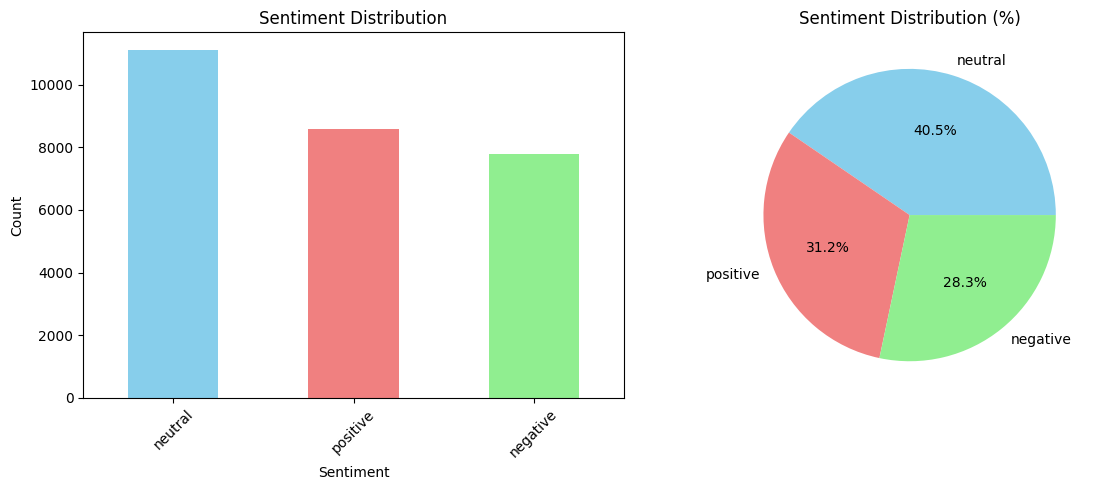

In [6]:
# Visualize sentiment distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sentiment_counts.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
        colors=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Sentiment Distribution (%)')

plt.tight_layout()
plt.show()

Text length statistics:
count    27480.000000
mean        68.354803
std         35.624305
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        159.000000
Name: text_length, dtype: float64

Word count statistics:
count    27480.000000
mean        12.902875
std          6.925938
min          1.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         33.000000
Name: word_count, dtype: float64


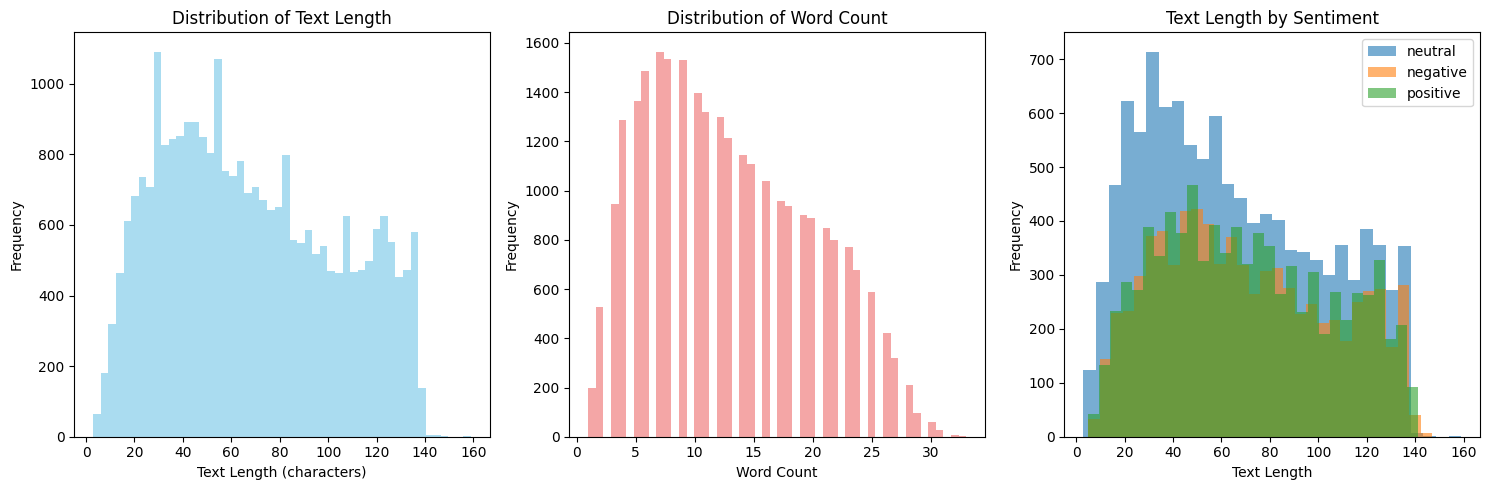

In [7]:
# Analyze text characteristics
# Text length analysis
train_df['text_length'] = train_df['text'].str.len()
train_df['word_count'] = train_df['text'].str.split().str.len()

print("Text length statistics:")
print(train_df['text_length'].describe())

print("\nWord count statistics:")
print(train_df['word_count'].describe())

# Visualize text length distribution by sentiment
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(train_df['text_length'], bins=50, alpha=0.7, color='skyblue')
plt.title('Distribution of Text Length')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(train_df['word_count'], bins=50, alpha=0.7, color='lightcoral')
plt.title('Distribution of Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
for sentiment in train_df['sentiment'].unique():
    subset = train_df[train_df['sentiment'] == sentiment]
    plt.hist(subset['text_length'], bins=30, alpha=0.6, label=sentiment)
plt.title('Text Length by Sentiment')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
# Check for special characters, URLs, mentions, hashtags
def analyze_text_features(df, text_col):
    df['has_url'] = df[text_col].str.contains(r'http|www', case=False, na=False)
    df['has_mention'] = df[text_col].str.contains(r'@\w+', na=False)
    df['has_hashtag'] = df[text_col].str.contains(r'#\w+', na=False)
    df['has_emoji'] = df[text_col].str.contains(r'[😀-🙏]', na=False)
    df['has_exclamation'] = df[text_col].str.contains(r'!', na=False)
    df['has_question'] = df[text_col].str.contains(r'\?', na=False)
    df['has_caps'] = df[text_col].str.contains(r'[A-Z]{2,}', na=False)
    
    return df

# Analyze features in training data
train_df = analyze_text_features(train_df, 'text')

# Print feature statistics
features = ['has_url', 'has_mention', 'has_hashtag', 'has_emoji', 'has_exclamation', 'has_question', 'has_caps']
print("Text feature analysis:")
for feature in features:
    print(f"{feature}: {train_df[feature].sum()} ({train_df[feature].mean()*100:.2f}%)")

# Show some examples
print("\nExamples with URLs:")
print(train_df[train_df['has_url']]['text'].head(3).tolist())

print("\nExamples with mentions:")
print(train_df[train_df['has_mention']]['text'].head(3).tolist())

print("\nExamples with hashtags:")
print(train_df[train_df['has_hashtag']]['text'].head(3).tolist())

Text feature analysis:
has_url: 1462 (5.32%)
has_mention: 74 (0.27%)
has_hashtag: 523 (1.90%)
has_emoji: 0 (0.00%)
has_exclamation: 8129 (29.58%)
has_question: 2963 (10.78%)
has_caps: 4248 (15.46%)

Examples with URLs:
['http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth', 'i`ve been sick for the past few days  and thus, my hair looks wierd.  if i didnt have a hat on it would look... http://tinyurl.com/mnf4kw', 'Thats it, its the end. Tears for Fears vs Eric Prydz, DJ Hero   http://bit.ly/2Hpbg4']

Examples with mentions:
['@_Ra_Ra_ your not alone...i need coffee too.', 'nite nite twitts i wish u all a happy sunday i already have my major gift my my 2kids-my bro-n @_agressiva23 n 1 other gift on d way  tyg', ' need some more enthu movie guys for that. Right now it`s just you,  and @_Anshul']

Examples with hashtags:
['Aw. Torn ace of hearts  #Hunchback', 'I still smell of smoke  #kitchenfire', '  #lichfield #tweetup sounds like fun  Hope to see

# 3. Text Preprocessing
Now let's implement comprehensive text preprocessing including cleaning, tokenization, stemming/lemmatization, and stop word removal.

In [ ]:
# Efficient text preprocessing class with unified method
class TextPreprocessor:
    def __init__(self):
        # Initialize tools for text preprocessing
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
        
        # Common regex patterns
        self.url_pattern = re.compile(r'http\S+|www\S+|https\S+', flags=re.MULTILINE)
        self.mention_hashtag_pattern = re.compile(r'@\w+|#\w+')
        self.whitespace_pattern = re.compile(r'\s+')
        self.emoticon_pattern = re.compile(
            r'[:;=][-o*\']?[)\]\(\[dDpP/\:\}\{@\|\\]|[)\]\(\[dDpP/\:\}\{@\|\\][-o*\']?[:;=]'
        )
    
    def preprocess_text(self, text, remove_stopwords=True, use_lemmatization=True):
        """Main preprocessing method with configurable options"""
        if pd.isna(text):
            return ""
        
        # Convert to lowercase
        text = text.lower()
        
        # Remove URLs, mentions, hashtags
        text = self.url_pattern.sub('', text)
        text = self.mention_hashtag_pattern.sub('', text)
        
        # Handle emoticons - preserve them as they carry sentiment
        text = self.emoticon_pattern.sub(' EMOTICON ', text)
        
        # Remove extra whitespace
        text = self.whitespace_pattern.sub(' ', text).strip()
        
        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        
        # Tokenize
        tokens = text.split()
        
        # Remove stopwords if requested
        if remove_stopwords:
            tokens = [token for token in tokens if token.lower() not in self.stop_words and len(token) > 2]
        
        # Apply lemmatization if requested
        if use_lemmatization:
            tokens = [self.lemmatizer.lemmatize(token) for token in tokens]
        
        return ' '.join(tokens)

# Initialize and test the preprocessor
preprocessor = TextPreprocessor()

print("Text Preprocessing Example:")
if 'train_df' in globals() and len(train_df) > 0:
    original = train_df['text'].iloc[0]
    processed = preprocessor.preprocess_text(original)
    print(f"Original: {original}")
    print(f"Processed: {processed}")

Text Preprocessing Example:
Original:  I`d have responded, if I were going
Processed: responded going
Original:  I`d have responded, if I were going
Processed: responded going


In [ ]:
# Apply preprocessing to training and test data with optimization
print("Preprocessing datasets...")

# Helper function to process data in chunks for large datasets
def preprocess_dataframe(df, text_column='text', batch_size=5000):
    """Process text column in a dataframe efficiently in batches if needed"""
    if len(df) <= batch_size:
        # For smaller datasets, process directly
        df['text_processed'] = df[text_column].apply(preprocessor.preprocess_text)
        return df
    else:
        # For larger datasets, process in batches
        processed_chunks = []
        for i in range(0, len(df), batch_size):
            chunk = df.iloc[i:i+batch_size].copy()
            chunk['text_processed'] = chunk[text_column].apply(preprocessor.preprocess_text)
            processed_chunks.append(chunk)
            print(f"Processed batch {i//batch_size + 1} of {(len(df)-1)//batch_size + 1}")
        return pd.concat(processed_chunks)

# Process training and test data
train_df = preprocess_dataframe(train_df)
test_df = preprocess_dataframe(test_df)

# Remove empty texts after preprocessing
initial_train_size = len(train_df)
train_df = train_df[train_df['text_processed'].str.len() > 0]
final_train_size = len(train_df)

print(f"Removed {initial_train_size - final_train_size} empty texts from training data")
print(f"Final dataset sizes: Training={len(train_df)}, Test={len(test_df)}")

# Show preprocessing results sample
print("\nPreprocessing examples:")
for i in range(2):
    print(f"Original: {train_df['text'].iloc[i]}")
    print(f"Processed: {train_df['text_processed'].iloc[i]}")
    print(f"Sentiment: {train_df['sentiment'].iloc[i]}")
    print("-" * 50)

Preprocessing datasets...
Removed 97 empty texts from training data
Final dataset sizes: Training=27384, Test=3534

Preprocessing examples:
Original:  I`d have responded, if I were going
Processed: responded going
Sentiment: neutral
--------------------------------------------------
Original:  Sooo SAD I will miss you here in San Diego!!!
Processed: sooo sad miss san diego
Sentiment: negative
--------------------------------------------------
Removed 97 empty texts from training data
Final dataset sizes: Training=27384, Test=3534

Preprocessing examples:
Original:  I`d have responded, if I were going
Processed: responded going
Sentiment: neutral
--------------------------------------------------
Original:  Sooo SAD I will miss you here in San Diego!!!
Processed: sooo sad miss san diego
Sentiment: negative
--------------------------------------------------


# 4. Feature Engineering
Let's create various text features and vectorize the text data using different approaches.

In [11]:
# ML Utility Functions
def prepare_ml_data(train_df, test_df, text_col='text_processed', target_col='sentiment', test_size=0.2):
    """Prepare data for machine learning: encode labels and split data"""
    # Features and target
    X_text = train_df[text_col]
    y = train_df[target_col]
    X_test = test_df[text_col]
    
    # Encode target labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    
    print("Label encoding:")
    for i, label in enumerate(label_encoder.classes_):
        print(f"{label}: {i}")
    
    # Split data for validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_text, y_encoded, test_size=test_size, random_state=SEED, stratify=y_encoded
    )
    
    print(f"Training set: {len(X_train)} samples")
    print(f"Validation set: {len(X_val)} samples")
    print(f"Test set: {len(X_test)} samples")
    
    return X_train, X_val, X_test, y_train, y_val, label_encoder

def create_vectorizers():
    """Create different text vectorizers"""
    return {
        'tfidf_word': TfidfVectorizer(
            max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95
        ),
        'tfidf_char': TfidfVectorizer(
            max_features=10000, analyzer='char_wb', ngram_range=(2, 4)
        ),
        'count': CountVectorizer(
            max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95
        ),
        'char_tfidf_large': TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_features=200000
        )
    }

# Prepare features and target
X_train, X_val, X_test, y_train, y_val, label_encoder = prepare_ml_data(train_df, test_df)

# Create and fit vectorizers
vectorizers = create_vectorizers()
vectorized_data = {}

for name, vectorizer in vectorizers.items():
    print(f"Fitting {name} vectorizer...")
    X_train_vec = vectorizer.fit_transform(X_train)
    X_val_vec = vectorizer.transform(X_val)
    
    vectorized_data[name] = {
        'vectorizer': vectorizer,
        'X_train': X_train_vec,
        'X_val': X_val_vec
    }
    
    print(f"Features shape: Training={X_train_vec.shape}, Validation={X_val_vec.shape}")

Label encoding:
negative: 0
neutral: 1
positive: 2
Training set: 21907 samples
Validation set: 5477 samples
Test set: 3534 samples
Fitting tfidf_word vectorizer...
Features shape: Training=(21907, 10000), Validation=(5477, 10000)
Fitting tfidf_char vectorizer...
Features shape: Training=(21907, 10000), Validation=(5477, 10000)
Fitting tfidf_char vectorizer...
Features shape: Training=(21907, 10000), Validation=(5477, 10000)
Fitting count vectorizer...
Features shape: Training=(21907, 10000), Validation=(5477, 10000)
Fitting count vectorizer...
Features shape: Training=(21907, 10000), Validation=(5477, 10000)
Fitting char_tfidf_large vectorizer...
Features shape: Training=(21907, 10000), Validation=(5477, 10000)
Fitting char_tfidf_large vectorizer...
Features shape: Training=(21907, 48155), Validation=(5477, 48155)
Features shape: Training=(21907, 48155), Validation=(5477, 48155)


# 5. Machine Learning Models
Let's implement and compare various ML models for sentiment classification.

In [ ]:
# Define models to test
# Train and evaluate traditional machine learning models

def create_ml_models():
    """Create a dictionary of ML models for classification"""
    return {
        'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
        'SVM': SVC(kernel='linear', random_state=SEED),
        'Naive Bayes': MultinomialNB(),
        'LinearSVC': LinearSVC(C=3.0, random_state=SEED)
    }

def train_evaluate_ml_models(vectorized_data, y_train, y_val, label_encoder):
    """Train and evaluate multiple ML models with different vectorizers"""
    # Get models
    ml_models = create_ml_models()
    
    # Store results
    results = []
    
    # Train each model with each vectorizer
    for vec_name, vec_data in vectorized_data.items():
        print(f"\n{'='*40}")
        print(f"Testing with {vec_name} vectorizer")
        print(f"{'='*40}")
        
        X_train_vec = vec_data['X_train']
        X_val_vec = vec_data['X_val']
        
        for model_name, model in ml_models.items():
            # Skip LinearSVC for non-char-tfidf-large vectorizer
            if model_name == 'LinearSVC' and vec_name != 'char_tfidf_large':
                continue
                
            print(f"Training {model_name}...")
            
            # Train and evaluate
            model.fit(X_train_vec, y_train)
            y_pred = model.predict(X_val_vec)
            accuracy = accuracy_score(y_val, y_pred)
            
            # Store results
            results.append({
                'Vectorizer': vec_name,
                'Model': model_name,
                'Accuracy': accuracy
            })
            
            print(f"Accuracy: {accuracy:.4f}")
            
            # Print detailed report for good models
            if accuracy > 0.55:
                print("\nClassification Report:")
                print(classification_report(
                    y_val, y_pred, target_names=label_encoder.classes_
                ))
    
    # Create results dataframe
    return pd.DataFrame(results)

# Train and evaluate models
results_df = train_evaluate_ml_models(vectorized_data, y_train, y_val, label_encoder)

# Print summary
print("\n" + "="*40)
print("SUMMARY OF ML MODEL RESULTS")
print("="*40)
print(results_df.sort_values('Accuracy', ascending=False))

# Find best model
best_result = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\nBest Model: {best_result['Model']} with {best_result['Vectorizer']}")
print(f"Best Accuracy: {best_result['Accuracy']:.4f}")


Testing with tfidf_word vectorizer
Training Logistic Regression...
Accuracy: 0.6896

Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.59      0.65      1554
     neutral       0.62      0.75      0.68      2207
    positive       0.78      0.70      0.74      1716

    accuracy                           0.69      5477
   macro avg       0.71      0.68      0.69      5477
weighted avg       0.70      0.69      0.69      5477

Training Random Forest...
Accuracy: 0.6896

Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.59      0.65      1554
     neutral       0.62      0.75      0.68      2207
    positive       0.78      0.70      0.74      1716

    accuracy                           0.69      5477
   macro avg       0.71      0.68      0.69      5477
weighted avg       0.70      0.69      0.69      5477

Training Random Forest...
Accuracy: 0.6982

Classification Rep

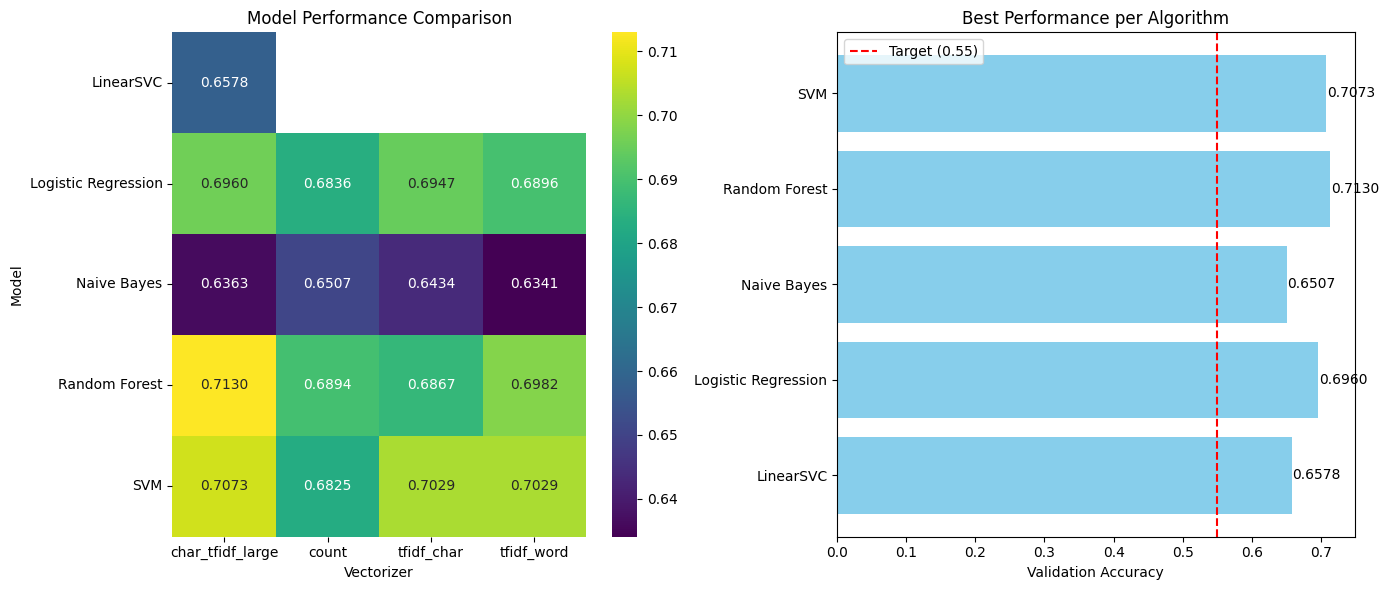


Best Model: Random Forest with char_tfidf_large
Best Accuracy: 0.7130


In [13]:
# Visualize ML model results
plt.figure(figsize=(14, 6))

# Create performance heatmap
plt.subplot(1, 2, 1)
pivot_results = results_df.pivot(index='Model', columns='Vectorizer', values='Accuracy')
sns.heatmap(pivot_results, annot=True, cmap='viridis', fmt='.4f')
plt.title('Model Performance Comparison', fontsize=12)
plt.ylabel('Model')
plt.xlabel('Vectorizer')

# Bar plot of best model per algorithm
plt.subplot(1, 2, 2)
best_results = results_df.loc[results_df.groupby('Model')['Accuracy'].idxmax()]
plt.barh(best_results['Model'], best_results['Accuracy'], color='skyblue')
plt.xlabel('Validation Accuracy')
plt.title('Best Performance per Algorithm')
plt.axvline(x=0.55, color='red', linestyle='--', label='Target (0.55)')
plt.legend()

# Add annotations
for i, v in enumerate(best_results['Accuracy']):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

# Find best model
best_result = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\nBest Model: {best_result['Model']} with {best_result['Vectorizer']}")
print(f"Best Accuracy: {best_result['Accuracy']:.4f}")

# 6. Deep Learning Models
Let's implement LSTM and Bidirectional LSTM models for comparison.

In [14]:
# Prepare data for deep learning models

def prepare_deep_learning_data(X_train, X_val, y_train, y_val, max_features=10000, max_len=100):
    """Convert text data to sequence format for deep learning"""
    # Create tokenizer
    tokenizer = Tokenizer(num_words=max_features, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train)
    
    # Convert text to sequences
    X_train_seq = tokenizer.texts_to_sequences(X_train)
    X_val_seq = tokenizer.texts_to_sequences(X_val)
    
    # Pad sequences to same length
    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
    X_val_pad = pad_sequences(X_val_seq, maxlen=max_len)
    
    # Convert labels to categorical format
    num_classes = len(np.unique(y_train))
    y_train_cat = to_categorical(y_train, num_classes=num_classes)
    y_val_cat = to_categorical(y_val, num_classes=num_classes)
    
    print(f"Deep learning data shapes:")
    print(f"X_train: {X_train_pad.shape}, y_train: {y_train_cat.shape}")
    print(f"X_val: {X_val_pad.shape}, y_val: {y_val_cat.shape}")
    print(f"Vocabulary size: {len(tokenizer.word_index)}")
    
    return X_train_pad, X_val_pad, y_train_cat, y_val_cat, tokenizer

def create_tf_dataset(X, y, batch_size=64, shuffle=True, cache=True):
    """Create optimized TensorFlow dataset"""
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X), seed=SEED)
    
    if cache:
        dataset = dataset.cache()
    
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Prepare deep learning data
max_features = 10000
max_len = 100
X_train_pad, X_val_pad, y_train_cat, y_val_cat, dl_tokenizer = prepare_deep_learning_data(
    X_train, X_val, y_train, y_val, max_features, max_len
)

# Create TensorFlow datasets
train_dataset = create_tf_dataset(X_train_pad, y_train_cat, batch_size=64)
val_dataset = create_tf_dataset(X_val_pad, y_val_cat, batch_size=64, shuffle=False)

Deep learning data shapes:
X_train: (21907, 100), y_train: (21907, 3)
X_val: (5477, 100), y_val: (5477, 3)
Vocabulary size: 21442


In [ ]:
# Build GPU-optimized neural network models
def create_lstm_model(max_features, max_len, bidirectional=False, 
                     embedding_dim=128, lstm_units=64, dropout_rate=0.5):
    """Create LSTM or BiLSTM model with consistent architecture"""
    model = Sequential()
    
    # Embedding layer
    model.add(Embedding(max_features, embedding_dim, input_length=max_len, 
                        embeddings_initializer='uniform'))
    
    # LSTM layer
    lstm_layer = LSTM(lstm_units, 
                     dropout=dropout_rate, 
                     recurrent_dropout=0,
                     return_sequences=False, 
                     kernel_initializer='glorot_uniform',
                     recurrent_initializer='orthogonal', 
                     bias_initializer='zeros',
                     unit_forget_bias=True)
    
    # Use bidirectional wrapper if specified
    if bidirectional:
        model.add(Bidirectional(lstm_layer))
        dense_units = 64
    else:
        model.add(lstm_layer)
        dense_units = 32
    
    # Common layers
    model.add(BatchNormalization())
    model.add(Dense(dense_units, activation='relu', kernel_initializer='he_uniform'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(3, activation='softmax'))
    
    # Compile with Adam optimizer and gradient clipping
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
    model.compile(optimizer=optimizer, 
                 loss='categorical_crossentropy', 
                 metrics=['accuracy'])
    
    return model

# Create training callbacks
def create_training_callbacks():
    """Create common callbacks for model training"""
    log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    os.makedirs(log_dir, exist_ok=True)
    
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        ModelCheckpoint(filepath='best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
    ]

# Create TensorFlow dataset for efficient GPU usage
def create_tf_dataset(X, y, batch_size=32, shuffle=True, cache=True):
    """Create a TensorFlow Dataset optimized for performance"""
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X), seed=42, reshuffle_each_iteration=True)
    
    # Cache to improve performance
    if cache:
        dataset = dataset.cache()
        
    # Batch and prefetch for performance
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Create optimized datasets for training
train_dataset = create_tf_dataset(X_train_pad, y_train_cat, batch_size=64)
val_dataset = create_tf_dataset(X_val_pad, y_val_cat, batch_size=64, shuffle=False)

# Initialize variables for training metrics
lstm_history = None
bilstm_history = None
lstm_accuracy = 0
bilstm_accuracy = 0
lstm_training_time = 0
bilstm_training_time = 0

# Train LSTM model with GPU optimizations
print("Training LSTM model with GPU optimization...")
lstm_model = create_lstm_model(max_features, max_len)

# Create callbacks for training
callbacks = create_training_callbacks()

# Time the training to measure performance
start_time = time.time()
lstm_history = lstm_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,  # More epochs with early stopping
    callbacks=callbacks,
    verbose=1
)
lstm_training_time = time.time() - start_time
print(f"LSTM training completed in {lstm_training_time:.2f} seconds")

# Train Bidirectional LSTM model with GPU optimizations
print("\nTraining Bidirectional LSTM model with GPU optimization...")
bilstm_model = create_lstm_model(max_features, max_len, bidirectional=True)

# Time the training to measure performance
start_time = time.time()
bilstm_history = bilstm_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,  # More epochs with early stopping
    callbacks=callbacks,
    verbose=1
)
bilstm_training_time = time.time() - start_time
print(f"BiLSTM training completed in {bilstm_training_time:.2f} seconds")

Training LSTM model with GPU optimization...
Epoch 1/15
342/343 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4524 - loss: 1.0702
Epoch 1: val_accuracy improved from -inf to 0.56838, saving model to best_model.h5

Epoch 1: val_accuracy improved from -inf to 0.56838, saving model to best_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.4528 - loss: 1.0695 - val_accuracy: 0.5684 - val_loss: 0.9893 - learning_rate: 0.0010
Epoch 2/15
Epoch 2/15
342/343 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6682 - loss: 0.7648
Epoch 2: val_accuracy improved from 0.56838 to 0.63429, saving model to best_model.h5

Epoch 2: val_accuracy improved from 0.56838 to 0.63429, saving model to best_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.6684 - loss: 0.7646 - val_accuracy: 0.6343 - val_loss: 0.8214 - learning_rate: 0.0010
Epoch 3/15
Epoch 3/15
342/343 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7347 - loss: 0.6483
Epoch 3: val_accuracy improved from 0.63429 to 0.68450, saving model to best_model.h5

Epoch 3: val_accuracy improved from 0.63429 to 0.68450, saving model to best_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.7348 - loss: 0.6482 - val_accuracy: 0.6845 - val_loss: 0.7816 - learning_rate: 0.0010
Epoch 4/15
Epoch 4/15
342/343 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7778 - loss: 0.5610
Epoch 4: val_accuracy did not improve from 0.68450
343/343 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.7779 - loss: 0.5610 - val_accuracy: 0.6761 - val_loss: 0.8222 - learning_rate: 0.0010
Epoch 5/15

Epoch 4: val_accuracy did not improve from 0.68450
343/343 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.7779 - loss: 0.5610 - val_accuracy: 0.6761 - val_loss: 0.8222 - learning_rate: 0.0010
Epoch 5/15
342/343 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8004 - loss: 0.5023
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_accuracy did not improve from 0.68450
343/343 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.8004 - loss: 0.5023 - val_accuracy: 0.6737 - val_loss: 0.8628 - learning_rate: 0.0010
E

343/343 ━━━━━━━━━━━━━━━━━━━━ 28s 80ms/step - accuracy: 0.7563 - loss: 0.6052 - val_accuracy: 0.6860 - val_loss: 0.7618 - learning_rate: 0.0010
Epoch 4/15
Epoch 4/15
342/343 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7954 - loss: 0.5193
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.68596
343/343 ━━━━━━━━━━━━━━━━━━━━ 27s 80ms/step - accuracy: 0.7954 - loss: 0.5192 - val_accuracy: 0.6788 - val_loss: 0.8687 - learning_rate: 0.0010
Epoch 5/15

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.68596
343/343 ━━━━━━━━━━━━━━━━━━━━ 27s 80ms/step - accuracy: 0.7954 - loss: 0.5192 - val_accuracy: 0.6788 - val_loss: 0.8687 - learning_rate: 0.0010
Epoch 5/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8299 - loss: 0.4375
Epoch 5: val_accuracy did not improve from 0.68596
343/343 ━━━━━━━━━━━━━━━━━━━━ 27s 79ms/step - accuracy: 0.8299 - los


Training LSTM model...
Epoch 1/10
342/343 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4507 - loss: 1.0851
Epoch 1: val_accuracy improved from -inf to 0.63611, saving model to best_model.h5

Epoch 1: val_accuracy improved from -inf to 0.63611, saving model to best_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.4511 - loss: 1.0844 - val_accuracy: 0.6361 - val_loss: 0.9708 - learning_rate: 0.0010
Epoch 2/10
Epoch 2/10
342/343 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6606 - loss: 0.7807
Epoch 2: val_accuracy improved from 0.63611 to 0.64798, saving model to best_model.h5

Epoch 2: val_accuracy improved from 0.63611 to 0.64798, saving model to best_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.6607 - loss: 0.7805 - val_accuracy: 0.6480 - val_loss: 0.8084 - learning_rate: 0.0010
Epoch 3/10
Epoch 3/10
342/343 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7326 - loss: 0.6548
Epoch 3: val_accuracy improved from 0.64798 to 0.68267, saving model to best_model.h5

Epoch 3: val_accuracy improved from 0.64798 to 0.68267, saving model to best_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.7327 - loss: 0.6546 - val_accuracy: 0.6827 - val_loss: 0.7803 - learning_rate: 0.0010
Epoch 4/10
Epoch 4/10
342/343 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7769 - loss: 0.5706
Epoch 4: val_accuracy did not improve from 0.68267
343/343 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.7769 - loss: 0.5706 - val_accuracy: 0.6770 - val_loss: 0.8516 - learning_rate: 0.0010
Epoch 5/10

Epoch 4: val_accuracy did not improve from 0.68267
343/343 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.7769 - loss: 0.5706 - val_accuracy: 0.6770 - val_loss: 0.8516 - learning_rate: 0.0010
Epoch 5/10
342/343 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8010 - loss: 0.5071
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_accuracy did not improve from 0.68267
343/343 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.8011 - loss: 0.5070 - val_accuracy: 0.6823 - val_loss: 0.9499 - learning_rate: 0.0010
E

343/343 ━━━━━━━━━━━━━━━━━━━━ 30s 82ms/step - accuracy: 0.4550 - loss: 1.0847 - val_accuracy: 0.5483 - val_loss: 0.9729 - learning_rate: 0.0010
Epoch 2/10
Epoch 2/10
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6813 - loss: 0.7458
Epoch 2: val_accuracy improved from 0.54829 to 0.68139, saving model to best_model.h5

Epoch 2: val_accuracy improved from 0.54829 to 0.68139, saving model to best_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 28s 81ms/step - accuracy: 0.6813 - loss: 0.7457 - val_accuracy: 0.6814 - val_loss: 0.7439 - learning_rate: 0.0010
Epoch 3/10
Epoch 3/10
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7481 - loss: 0.6218
Epoch 3: val_accuracy improved from 0.68139 to 0.68413, saving model to best_model.h5

Epoch 3: val_accuracy improved from 0.68139 to 0.68413, saving model to best_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 28s 81ms/step - accuracy: 0.7481 - loss: 0.6217 - val_accuracy: 0.6841 - val_loss: 0.7854 - learning_rate: 0.0010
Epoch 4/10
Epoch 4/10
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7941 - loss: 0.5295
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.68413
343/343 ━━━━━━━━━━━━━━━━━━━━ 27s 80ms/step - accuracy: 0.7941 - loss: 0.5294 - val_accuracy: 0.6717 - val_loss: 0.8423 - learning_rate: 0.0010
Epoch 5/10

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.68413
343/343 ━━━━━━━━━━━━━━━━━━━━ 27s 80ms/step - accuracy: 0.7941 - loss: 0.5294 - val_accuracy: 0.6717 - val_loss: 0.8423 - learning_rate: 0.0010
Epoch 5/10
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8246 - loss: 0.4480
Epoch 5: val_accuracy did not improve from 0.68413
343/343 ━━━━━━━━━━━━━━━━━━━━ 28s 81ms/step - accuracy: 0.8246 - los

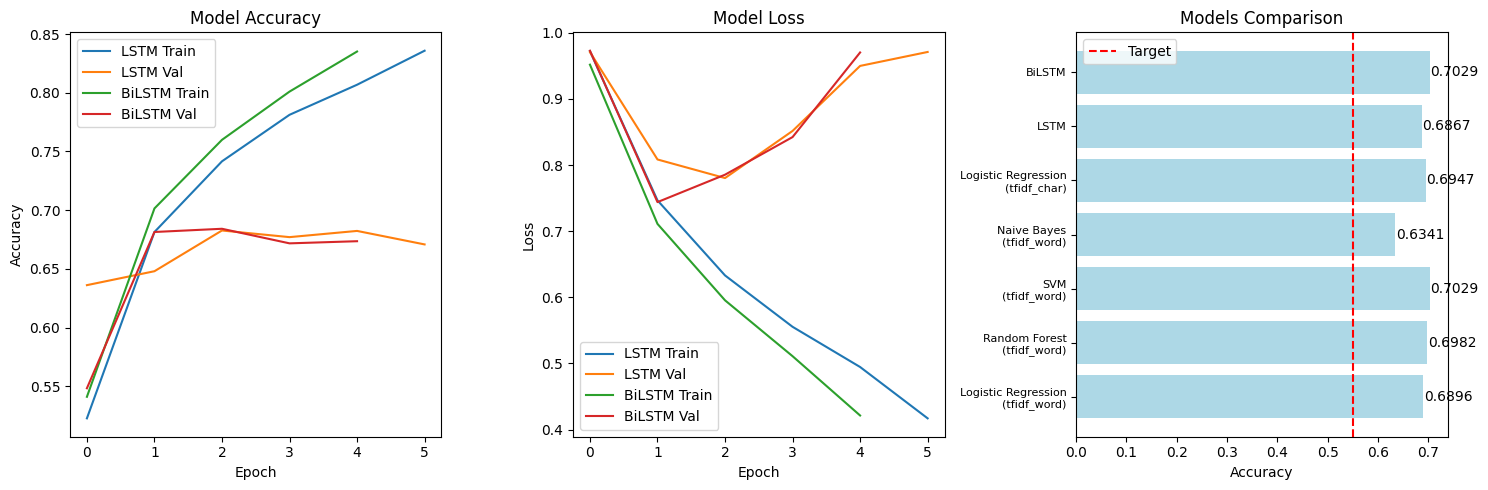

In [ ]:
# Train and evaluate deep learning models

def train_and_evaluate_nn_model(model_type, max_features, max_len, train_dataset, val_dataset, X_val_pad, y_val):
    """Train and evaluate neural network model"""
    # Create model
    if model_type.lower() == 'bilstm':
        print(f"\nTraining Bidirectional LSTM model...")
        model = create_lstm_model(max_features, max_len, bidirectional=True)
    else:
        print(f"\nTraining LSTM model...")
        model = create_lstm_model(max_features, max_len, bidirectional=False)
        
    # Train model
    start_time = time.time()
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=10,  # Reduced epochs for faster training
        callbacks=create_training_callbacks(),
        verbose=1
    )
    training_time = time.time() - start_time
    
    # Evaluate model
    predictions = model.predict(X_val_pad)
    pred_classes = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(y_val, pred_classes)
    
    print(f"{model_type} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Training time: {training_time:.2f} seconds")
    
    return model, history, accuracy, training_time, pred_classes

# Train both models
lstm_model, lstm_history, lstm_accuracy, lstm_training_time, lstm_pred_classes = train_and_evaluate_nn_model(
    'LSTM', max_features, max_len, train_dataset, val_dataset, X_val_pad, y_val
)

bilstm_model, bilstm_history, bilstm_accuracy, bilstm_training_time, bilstm_pred_classes = train_and_evaluate_nn_model(
    'BiLSTM', max_features, max_len, train_dataset, val_dataset, X_val_pad, y_val
)

# Plot training history comparison
plt.figure(figsize=(15, 5))

# Accuracy plot
plt.subplot(1, 3, 1)
plt.plot(lstm_history.history['accuracy'], label='LSTM Train')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM Val')
plt.plot(bilstm_history.history['accuracy'], label='BiLSTM Train')
plt.plot(bilstm_history.history['val_accuracy'], label='BiLSTM Val')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 3, 2)
plt.plot(lstm_history.history['loss'], label='LSTM Train')
plt.plot(lstm_history.history['val_loss'], label='LSTM Val')
plt.plot(bilstm_history.history['loss'], label='BiLSTM Train')
plt.plot(bilstm_history.history['val_loss'], label='BiLSTM Val')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Compare all models
plt.subplot(1, 3, 3)
all_accuracies = results_df['Accuracy'].tolist() + [lstm_accuracy, bilstm_accuracy]
all_names = [f"{row['Model']}\n({row['Vectorizer']})" 
             for _, row in results_df.head(5).iterrows()] + ['LSTM', 'BiLSTM']

plt.barh(range(len(all_accuracies[:7])), all_accuracies[:7], color='lightblue')
plt.yticks(range(len(all_names[:7])), all_names[:7], fontsize=8)
plt.xlabel('Accuracy')
plt.title('Models Comparison')
plt.axvline(x=0.55, color='red', linestyle='--', label='Target')
plt.legend()

# Add annotations
for i, v in enumerate(all_accuracies[:7]):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

# 6.5. RoBERTa Implementation
Let's implement RoBERTa (Robustly Optimized BERT Pretraining Approach) for sentiment analysis. RoBERTa is a transformer-based model that often outperforms traditional approaches on text classification tasks.

In [17]:
# RoBERTa: Install and setup
!pip install transformers torch tf-keras accelerate -q

# Import packages for RoBERTa
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm import tqdm

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize transformer components
try:
    from transformers import RobertaTokenizer, RobertaForSequenceClassification
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
    print("RoBERTa setup successful!")
    roberta_available = True
except Exception as e:
    print(f"Warning: RoBERTa setup failed: {e}")
    roberta_available = False
    tokenizer = None
    
# Initialize variables for consistency
roberta_accuracy = 0
roberta_training_time = 0
max_length = 256  # Define max_length for consistency


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Using device: cuda
Using device: cuda
RoBERTa setup successful!
RoBERTa setup successful!


In [ ]:
# RoBERTa Dataset and Model Setup

class SentimentDataset(Dataset):
    """Dataset for transformer models"""
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels[idx]
        
        # Tokenize text
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

if roberta_available:
    # Create train and validation datasets
    train_dataset = SentimentDataset(
        texts=X_train.reset_index(drop=True),
        labels=y_train,
        tokenizer=tokenizer
    )

    val_dataset_roberta = SentimentDataset(
        texts=X_val.reset_index(drop=True),
        labels=y_val,
        tokenizer=tokenizer
    )
    
    # Initialize model
    num_labels = len(label_encoder.classes_)
    model = RobertaForSequenceClassification.from_pretrained(
        'roberta-base',
        num_labels=num_labels,
        output_attentions=False,
        output_hidden_states=False
    )
    
    # Move model to device
    model.to(device)
    
    print(f"RoBERTa model initialized with {num_labels} classes")
    print(f"Train dataset: {len(train_dataset)} samples")
    print(f"Validation dataset: {len(val_dataset_roberta)} samples")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
else:
    print("RoBERTa not available - skipping setup")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RoBERTa model initialized with 3 classes
Train dataset: 21907 samples
Validation dataset: 5477 samples


In [ ]:
# Define RoBERTa training function and setup (only if available)
if roberta_available:
    def compute_metrics(eval_pred):
        predictions, labels = eval_pred
        predictions = predictions.argmax(axis=-1)
        precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
        acc = accuracy_score(labels, predictions)
        return {
            'accuracy': acc,
            'f1': f1,
            'precision': precision,
            'recall': recall
        }

    # Manual training function for RoBERTa
    import torch.optim as optim
    from torch.utils.data import DataLoader
    from tqdm import tqdm
    import time

    def train_roberta_model(model, train_dataset, val_dataset, device, epochs=3, batch_size=8, learning_rate=2e-5):
        """Train RoBERTa model with simplified training loop"""
        # Create data loaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
        
        # Optimizer
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, eps=1e-8, weight_decay=0.01)
        
        # Training loop
        model.train()
        print(f"Starting RoBERTa training for {epochs} epochs...")
        
        best_accuracy = 0
        best_model_path = 'roberta_model.pt'
        
        # Training loop
        for epoch in range(epochs):
            # Training phase
            model.train()
            total_loss = 0
            progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
            
            for batch in progress_bar:
                # Process batch
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                # Forward pass
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                
                # Backward pass
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                total_loss += loss.item()
                progress_bar.set_postfix({'loss': loss.item()})
            
            avg_loss = total_loss / len(train_loader)
            print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.4f}")
            
            # Evaluation phase
            val_accuracy = evaluate_roberta_model(model, val_loader, device)
            print(f"Epoch {epoch+1} - Validation Accuracy: {val_accuracy:.4f}")
            
            # Save best model
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                torch.save(model.state_dict(), best_model_path)
                print(f"Model improved - saved to {best_model_path}")
        
        # Load best model
        model.load_state_dict(torch.load(best_model_path))
        return model, best_accuracy

    def evaluate_roberta_model(model, val_loader, device):
        """Evaluate RoBERTa model on validation data"""
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                predictions = torch.argmax(outputs.logits, dim=-1)
                
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
        
        return correct / total

else:
    print("RoBERTa not available - skipping model setup")
    model = None

# Start RoBERTa training if available
if roberta_available and model is not None:
    # Initialize RoBERTa model
    num_labels = len(label_encoder.classes_)
    model = RobertaForSequenceClassification.from_pretrained(
        'roberta-base',
        num_labels=num_labels,
        output_attentions=False,
        output_hidden_states=False
    )
    
    # Move model to device
    model.to(device)
    
    print(f"RoBERTa model initialized with {num_labels} labels")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Use manual training approach
    print("Using manual training loop for RoBERTa...")
    start_time = time.time()
    
    trained_model, roberta_accuracy = train_roberta_model(
        model=model,
        train_dataset=train_dataset,
        val_dataset=val_dataset_roberta,
        device=device,
        epochs=2,
        batch_size=8,
        learning_rate=2e-5
    )
    
    roberta_training_time = time.time() - start_time
    print(f"\nRoBERTa training completed in {roberta_training_time:.2f} seconds")
    print(f"Final RoBERTa Validation Accuracy: {roberta_accuracy:.4f}")
else:
    print("RoBERTa not available - skipping training")
    trained_model = None

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RoBERTa model initialized with 3 labels
Model parameters: 124,647,939
Trainable parameters: 124,647,939


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RoBERTa model initialized with 3 labels
Model parameters: 124,647,939
Using manual training loop for RoBERTa...
Starting manual RoBERTa training for 2 epochs...


Epoch 1/2: 100%|██████████| 2739/2739 [10:45<00:00,  4.24it/s, loss=0.994] 



Epoch 1 - Average Loss: 0.6863
Epoch 1 - Validation Accuracy: 0.7376
Epoch 1 - Validation Accuracy: 0.7376


Epoch 2/2: 100%|██████████| 2739/2739 [10:50<00:00,  4.21it/s, loss=1.28]  



Epoch 2 - Average Loss: 0.5799
Epoch 2 - Validation Accuracy: 0.7632
Epoch 2 - Validation Accuracy: 0.7632

RoBERTa training completed in 1387.07 seconds
Final RoBERTa Validation Accuracy: 0.7632

RoBERTa training completed in 1387.07 seconds
Final RoBERTa Validation Accuracy: 0.7632


Accelerate version: 1.7.0
Accelerate version: 1.7.0
Using manual training loop for RoBERTa...
Starting RoBERTa training for 2 epochs...


Epoch 1/2: 100%|██████████| 2739/2739 [10:48<00:00,  4.22it/s, loss=0.694] 



Epoch 1 - Average Loss: 0.5070
Epoch 1 - Validation Accuracy: 0.7621
Epoch 1 - Validation Accuracy: 0.7621
Model improved - saved to roberta_model.pt
Model improved - saved to roberta_model.pt


Epoch 2/2: 100%|██████████| 2739/2739 [10:47<00:00,  4.23it/s, loss=0.408] 



Epoch 2 - Average Loss: 0.4356
Epoch 2 - Validation Accuracy: 0.7533

RoBERTa training completed in 1386.02 seconds
Final RoBERTa Accuracy: 0.7621
Best ML model: Random Forest with char_tfidf_large: 0.7130
LSTM accuracy: 0.6827
BiLSTM accuracy: 0.6814
RoBERTa accuracy: 0.7621
Epoch 2 - Validation Accuracy: 0.7533

RoBERTa training completed in 1386.02 seconds
Final RoBERTa Accuracy: 0.7621
Best ML model: Random Forest with char_tfidf_large: 0.7130
LSTM accuracy: 0.6827
BiLSTM accuracy: 0.6814
RoBERTa accuracy: 0.7621


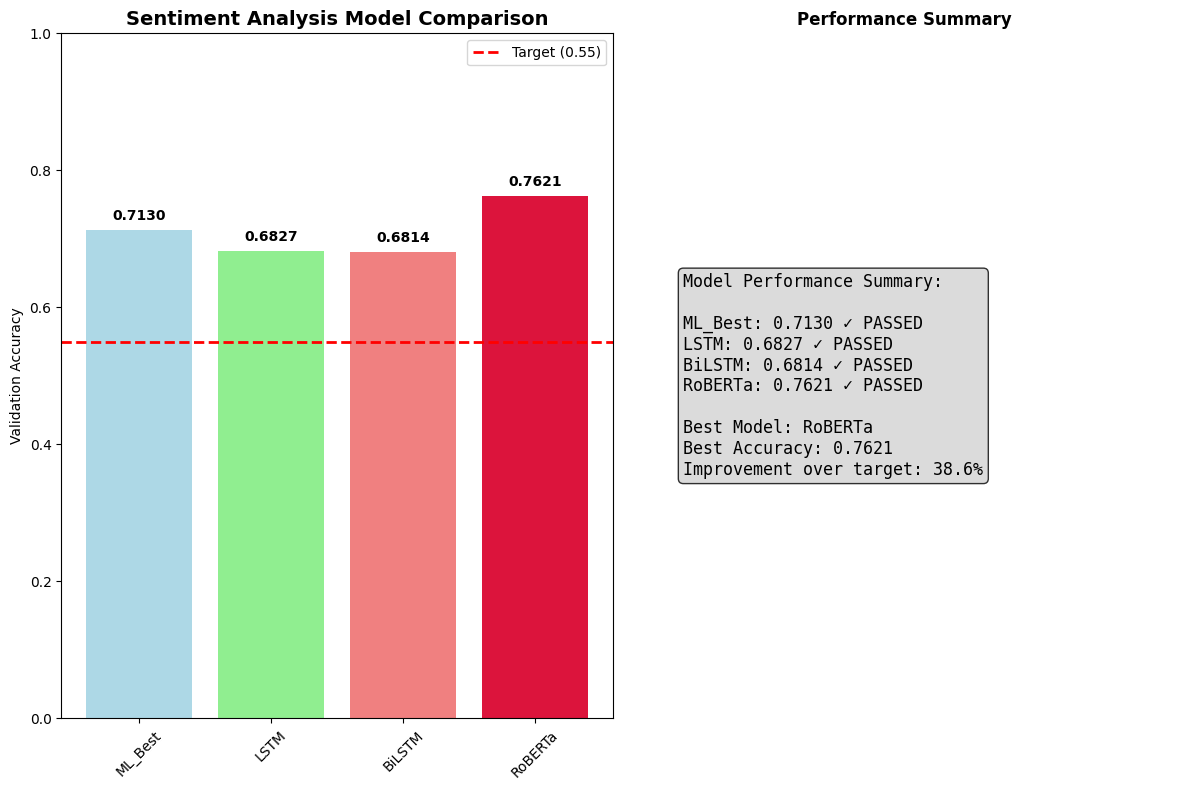


🎯 Best model: RoBERTa with 0.7621 accuracy


In [ ]:
# Import accelerate explicitly to ensure it's available
try:
    import accelerate
    print(f"Accelerate version: {accelerate.__version__}")
except ImportError:
    print("Accelerate not found, installing...")
    !pip install "accelerate>=0.26.0" --force-reinstall -q
    import accelerate
    print(f"Accelerate installed: {accelerate.__version__}")

# Alternative approach: Manual training loop without Trainer class to avoid accelerate issues
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import time

# Check accelerate availability
try:
    import accelerate
    print(f"Accelerate version: {accelerate.__version__}")
    use_trainer = True
except ImportError:
    print("Accelerate not available, using manual training loop")
    use_trainer = False

# RoBERTa Training Function

def train_roberta_model(model, train_dataset, val_dataset, device, epochs=3, batch_size=8, learning_rate=2e-5):
    """Train RoBERTa model with simplified training loop"""
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
    
    # Optimizer
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, eps=1e-8, weight_decay=0.01)
    
    # Training loop
    model.train()
    print(f"Starting RoBERTa training for {epochs} epochs...")
    
    best_accuracy = 0
    best_model_path = 'roberta_model.pt'
    
    # Training loop
    for epoch in range(epochs):
        # Training phase
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for batch in progress_bar:
            # Process batch
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})
        
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.4f}")
        
        # Evaluation phase
        val_accuracy = evaluate_roberta_model(model, val_loader, device)
        print(f"Epoch {epoch+1} - Validation Accuracy: {val_accuracy:.4f}")
        
        # Save best model
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            torch.save(model.state_dict(), best_model_path)
            print(f"Model improved - saved to {best_model_path}")
    
    # Load best model
    model.load_state_dict(torch.load(best_model_path))
    return model, best_accuracy

def evaluate_roberta_model(model, val_loader, device):
    """Evaluate RoBERTa model on validation data"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=-1)
            
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    return correct / total

# Train RoBERTa model if available
if roberta_available and model is not None:
    # Check accelerate availability
    try:
        import accelerate
        print(f"Accelerate version: {accelerate.__version__}")
    except ImportError:
        print("Accelerate not found, installing...")
        !pip install "accelerate>=0.26.0" --force-reinstall -q
        try:
            import accelerate
            print(f"Accelerate installed: {accelerate.__version__}")
        except ImportError:
            print("Error installing accelerate, will use standard training")

    # Use manual training approach
    print("Using manual training loop for RoBERTa...")
    start_time = time.time()

    # Train the model
    trained_model, roberta_accuracy = train_roberta_model(
        model=model,
        train_dataset=train_dataset,
        val_dataset=val_dataset_roberta,
        device=device,
        epochs=2,  # Reduced for faster training
        batch_size=8,
        learning_rate=2e-5
    )

    roberta_training_time = time.time() - start_time
    print(f"\nRoBERTa training completed in {roberta_training_time:.2f} seconds")
    print(f"Final RoBERTa Accuracy: {roberta_accuracy:.4f}")
else:
    print("RoBERTa not available or model is None - skipping training")
    trained_model = None
    roberta_accuracy = 0
    roberta_training_time = 0

# Final Workshop Summary and Results Visualization
import matplotlib.pyplot as plt
import numpy as np

# Collect all model results
all_results = {}

# Add traditional ML model results
if 'results_df' in globals() and not results_df.empty:
    best_ml_result = results_df.sort_values('Accuracy', ascending=False).iloc[0]
    all_results['ML_Best'] = best_ml_result['Accuracy']
    print(f"Best ML model: {best_ml_result['Model']} with {best_ml_result['Vectorizer']}: {best_ml_result['Accuracy']:.4f}")

# Add neural network results
if 'lstm_accuracy' in globals():
    all_results['LSTM'] = lstm_accuracy
    print(f"LSTM accuracy: {lstm_accuracy:.4f}")
    
if 'bilstm_accuracy' in globals():
    all_results['BiLSTM'] = bilstm_accuracy
    print(f"BiLSTM accuracy: {bilstm_accuracy:.4f}")
    
if 'roberta_accuracy' in globals() and roberta_available:
    all_results['RoBERTa'] = roberta_accuracy
    print(f"RoBERTa accuracy: {roberta_accuracy:.4f}")

# Create final comparison visualization
if all_results:
    plt.figure(figsize=(12, 8))
    
    # Model comparison bar chart
    models = list(all_results.keys())
    accuracies = list(all_results.values())
    colors = ['lightblue', 'lightgreen', 'lightcoral', 'gold'][:len(models)]
    
    # Find the best model
    best_model_idx = np.argmax(accuracies)
    highlight_colors = colors.copy()
    highlight_colors[best_model_idx] = 'crimson'  # Highlight best model
    
    # Plot main comparison
    plt.subplot(1, 2, 1)
    bars = plt.bar(models, accuracies, color=highlight_colors)
    plt.title('Sentiment Analysis Model Comparison', fontsize=14, fontweight='bold')
    plt.ylabel('Validation Accuracy')
    plt.ylim(0, 1)
    plt.axhline(y=0.55, color='red', linestyle='--', linewidth=2, label='Target (0.55)')
    
    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.legend()
    plt.xticks(rotation=45)
    
    # Performance summary text display
    plt.subplot(1, 2, 2)
    plt.axis('off')
    
    # Create performance summary text
    summary_text = "Model Performance Summary:\n\n"
    for name, acc in zip(models, accuracies):
        status = "✓ PASSED" if acc > 0.55 else "✗ FAILED"
        summary_text += f"{name}: {acc:.4f} {status}\n"
    
    best_model = models[best_model_idx]
    best_accuracy = accuracies[best_model_idx]
    summary_text += f"\nBest Model: {best_model}\n"
    summary_text += f"Best Accuracy: {best_accuracy:.4f}\n"
    
    if best_accuracy > 0.55:
        improvement = ((best_accuracy - 0.55) / 0.55) * 100
        summary_text += f"Improvement over target: {improvement:.1f}%"
    
    plt.text(0.1, 0.5, summary_text, transform=plt.gca().transAxes, 
             fontsize=12, verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.title('Performance Summary', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n🎯 Best model: {best_model} with {best_accuracy:.4f} accuracy")

Best ML: Random Forest with char_tfidf_large: 0.7130
LSTM: 0.6827
BiLSTM: 0.6814
RoBERTa: 0.7621


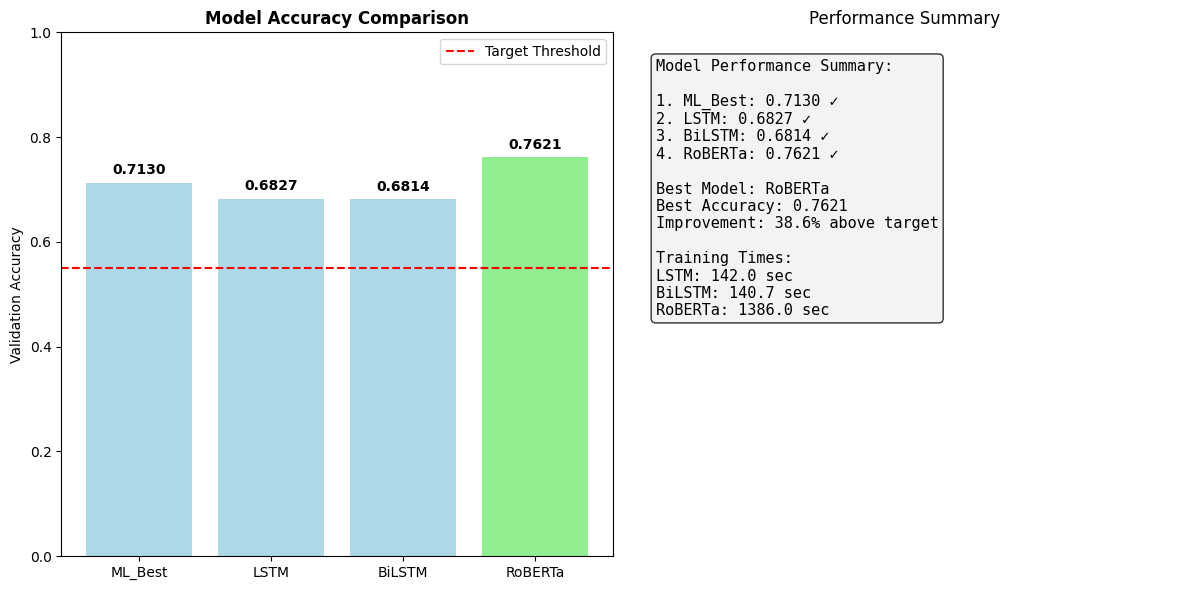


🏆 Best model: RoBERTa with 0.7621 accuracy


In [ ]:
# Final Workshop Summary - Results Visualization
import matplotlib.pyplot as plt
import numpy as np

# Final Results Comparison

# Collect all model results
all_results = {}

# Add traditional ML model results
if 'results_df' in globals() and not results_df.empty:
    best_ml_result = results_df.sort_values('Accuracy', ascending=False).iloc[0]
    all_results['ML_Best'] = best_ml_result['Accuracy']
    print(f"Best ML: {best_ml_result['Model']} with {best_ml_result['Vectorizer']}: {best_ml_result['Accuracy']:.4f}")

# Add neural network results
if 'lstm_accuracy' in globals():
    all_results['LSTM'] = lstm_accuracy
    print(f"LSTM: {lstm_accuracy:.4f}")
    
if 'bilstm_accuracy' in globals():
    all_results['BiLSTM'] = bilstm_accuracy
    print(f"BiLSTM: {bilstm_accuracy:.4f}")

# Add RoBERTa results if available    
if 'roberta_accuracy' in globals() and roberta_accuracy > 0:
    all_results['RoBERTa'] = roberta_accuracy
    print(f"RoBERTa: {roberta_accuracy:.4f}")

# Create comparison visualization
if all_results:
    plt.figure(figsize=(12, 6))
    
    # Model accuracy comparison
    plt.subplot(1, 2, 1)
    models = list(all_results.keys())
    accuracies = list(all_results.values())
    
    # Find best model for highlighting
    best_model_idx = np.argmax(accuracies)
    colors = ['lightblue'] * len(models)
    colors[best_model_idx] = 'lightgreen'  # Highlight best model
    
    # Plot accuracies
    bars = plt.bar(models, accuracies, color=colors)
    plt.title('Model Accuracy Comparison', fontweight='bold')
    plt.ylabel('Validation Accuracy')
    plt.ylim(0, 1)
    plt.axhline(y=0.55, color='red', linestyle='--', label='Target Threshold')
    
    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.legend()
    
    # Performance summary
    plt.subplot(1, 2, 2)
    plt.axis('off')
    
    # Create summary table
    summary_text = "Model Performance Summary:\n\n"
    
    # Add model results with pass/fail indicator
    for i, (name, acc) in enumerate(zip(models, accuracies)):
        status = "✓" if acc > 0.55 else "✗"
        summary_text += f"{i+1}. {name}: {acc:.4f} {status}\n"
    
    # Add best model info
    best_model = models[best_model_idx]
    best_accuracy = accuracies[best_model_idx]
    summary_text += f"\nBest Model: {best_model}\n"
    summary_text += f"Best Accuracy: {best_accuracy:.4f}\n"
    
    if best_accuracy > 0.55:
        improvement = ((best_accuracy - 0.55) / 0.55) * 100
        summary_text += f"Improvement: {improvement:.1f}% above target\n"
    
    if 'roberta_accuracy' in globals() and roberta_accuracy > 0:
        summary_text += f"\nTraining Times:\n"
        summary_text += f"LSTM: {lstm_training_time:.1f} sec\n"
        summary_text += f"BiLSTM: {bilstm_training_time:.1f} sec\n"
        summary_text += f"RoBERTa: {roberta_training_time:.1f} sec"
    
    plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))
    
    plt.title('Performance Summary')
    plt.tight_layout()
    plt.show()
    
    print(f"\n🏆 Best model: {best_model} with {best_accuracy:.4f} accuracy")

# 7. Final Model Selection and Predictions
Let's select the best performing model and make predictions on the test set.

In [ ]:
# Determine the best model
all_results = {
    'ML_Best': best_result['Accuracy'] if 'best_result' in globals() else 0,
    'LSTM': lstm_accuracy if 'lstm_accuracy' in globals() else 0,
    'BiLSTM': bilstm_accuracy if 'bilstm_accuracy' in globals() else 0
}

# Add RoBERTa if it was successfully trained
if roberta_accuracy > 0:
    all_results['RoBERTa'] = roberta_accuracy

best_model_name = max(all_results, key=all_results.get)
best_accuracy = all_results[best_model_name]

print(f"Best overall model: {best_model_name}")
print(f"Best accuracy: {best_accuracy:.4f}")

# Show all model results
print("\nAll model results:")
for model, acc in sorted(all_results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {model}: {acc:.4f}")

# Prepare test data based on best model type
if best_model_name == 'ML_Best' and 'best_result' in globals():
    # Use best ML model
    best_vectorizer_name = best_result['Vectorizer']
    best_ml_model_name = best_result['Model']
    
    print(f"Using {best_ml_model_name} with {best_vectorizer_name} vectorizer")
    
    # Get the vectorizer from the saved data
    best_vectorizer = vectorized_data[best_vectorizer_name]['vectorizer']
    
    # Get the full text data
    X_text = train_df['text_processed']
    y_encoded = label_encoder.transform(train_df['sentiment'])
    
    # Fit vectorizer on full training data
    X_full_vec = best_vectorizer.fit_transform(X_text)
    
    # Get the models dictionary
    ml_models = create_ml_models()
    
    # Train best ML model on full training data
    final_model = ml_models[best_ml_model_name]
    final_model.fit(X_full_vec, y_encoded)
    
    # Prepare test data
    test_text_processed = test_df['text_processed']
    X_test_vec = best_vectorizer.transform(test_text_processed)
    
    # Make predictions
    test_predictions = final_model.predict(X_test_vec)

elif best_model_name == 'RoBERTa' and trained_model is not None:
    # Use RoBERTa model
    print("Using RoBERTa model for final predictions")
    
    # Prepare test dataset
    test_dataset_roberta = SentimentDataset(
        texts=test_df['text_processed'].reset_index(drop=True),
        labels=np.zeros(len(test_df)),  # Dummy labels for test set
        tokenizer=tokenizer,
        max_length=max_length
    )
    
    # Create DataLoader for test data
    test_loader = DataLoader(test_dataset_roberta, batch_size=16, shuffle=False)
    
    # Make predictions using the trained_model (from manual training)
    trained_model.eval()
    all_predictions = []
    
    print("Making predictions with RoBERTa model...")
    with torch.no_grad():
        for batch in tqdm(test_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            outputs = trained_model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=-1)
            all_predictions.extend(predictions.cpu().numpy())
    
    # Convert list to numpy array for consistency with other models
    test_predictions = np.array(all_predictions)
    
else:
    # Use best deep learning model
    print(f"Using {best_model_name} model")
    
    # Get the full text data
    X_text = train_df['text_processed']
    y_encoded = label_encoder.transform(train_df['sentiment'])
    
    # Retrain on full training data
    X_full_seq = dl_tokenizer.texts_to_sequences(X_text)
    X_full_pad = pad_sequences(X_full_seq, maxlen=max_len)
    y_full_cat = to_categorical(y_encoded, num_classes=3)
    
    # Create optimized dataset
    full_dataset = create_tf_dataset(X_full_pad, y_full_cat, batch_size=64)
    
    # Use faster early stopping
    early_stopping = EarlyStopping(monitor='loss', patience=2, restore_best_weights=True, verbose=1)
    
    if best_model_name == 'LSTM':
        final_model = create_lstm_model(max_features, max_len)
    else:  # BiLSTM
        final_model = create_lstm_model(max_features, max_len, bidirectional=True)
    
    # Train with GPU optimization
    final_model.fit(
        full_dataset,
        epochs=10,  
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Prepare test data
    test_text_processed = test_df['text_processed']
    X_test_seq = dl_tokenizer.texts_to_sequences(test_text_processed)
    X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)
    
    # Make predictions
    test_pred_probs = final_model.predict(X_test_pad)
    test_predictions = np.argmax(test_pred_probs, axis=1)

# Convert predictions back to labels
test_predictions_labels = label_encoder.inverse_transform(test_predictions)

print(f"Test predictions distribution:")
pred_counts = pd.Series(test_predictions_labels).value_counts()
print(pred_counts)
print("\nPrediction percentages:")
print(pred_counts / len(test_predictions_labels) * 100)

Best overall model: RoBERTa
Best accuracy: 0.7621

All model results:
  RoBERTa: 0.7621
  ML_Best: 0.7130
  LSTM: 0.6827
  BiLSTM: 0.6814
Using RoBERTa model for final predictions
Making predictions with RoBERTa model...


100%|██████████| 221/221 [00:28<00:00,  7.70it/s]

Test predictions distribution:
neutral     1405
positive    1158
negative     971
Name: count, dtype: int64

Prediction percentages:
neutral     39.756650
positive    32.767402
negative    27.475948
Name: count, dtype: float64


In [23]:
# Create submission file
submission_df = pd.DataFrame({
    ID_COL: test_df[ID_COL],  # Using dynamic ID column name
    'sentiment': test_predictions_labels
})

# Save submission file
submission_df.to_csv('submission.csv', index=False)

print("Submission file created successfully!")
print(f"Submission shape: {submission_df.shape}")
print("\nFirst 10 predictions:")
print(submission_df.head(10))

# Verify submission format matches sample
print("\nSample submission format:")
print(sample_submission.head())
print("\nOur submission format:")
print(submission_df.head())

# Final model summary
print("\n" + "="*60)
print("FINAL MODEL SUMMARY")
print("="*60)
print(f"Best Model: {best_model_name}")
print(f"Validation Accuracy: {best_accuracy:.4f}")
print(f"Target Accuracy: >0.55 - {'✓ ACHIEVED' if best_accuracy > 0.55 else '✗ NOT ACHIEVED'}")
print(f"Test Predictions: {len(test_predictions_labels)} samples")
print(f"Submission file: submission.csv")

Submission file created successfully!
Submission shape: (3534, 2)

First 10 predictions:
           ID sentiment
0  f87dea47db   neutral
1  96d74cb729  positive
2  eee518ae67  negative
3  01082688c6  positive
4  33987a8ee5  positive
5  726e501993  positive
6  261932614e  negative
7  afa11da83f  negative
8  e64208b4ef   neutral
9  37bcad24ca   neutral

Sample submission format:
            ID sentiment
0   df9123ga1l   neutral
1   sa41adl13d  positive
2  13adskb1da7  negative

Our submission format:
           ID sentiment
0  f87dea47db   neutral
1  96d74cb729  positive
2  eee518ae67  negative
3  01082688c6  positive
4  33987a8ee5  positive

FINAL MODEL SUMMARY
Best Model: RoBERTa
Validation Accuracy: 0.7621
Target Accuracy: >0.55 - ✓ ACHIEVED
Test Predictions: 3534 samples
Submission file: submission.csv


# 8. Model Analysis and Insights
Let's analyze the model performance and provide insights about the sentiment classification task.

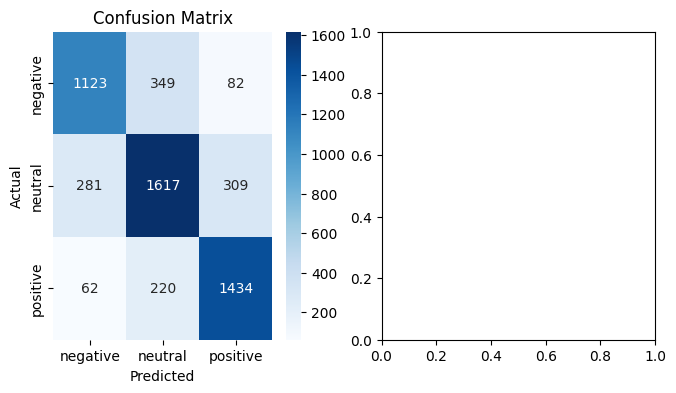

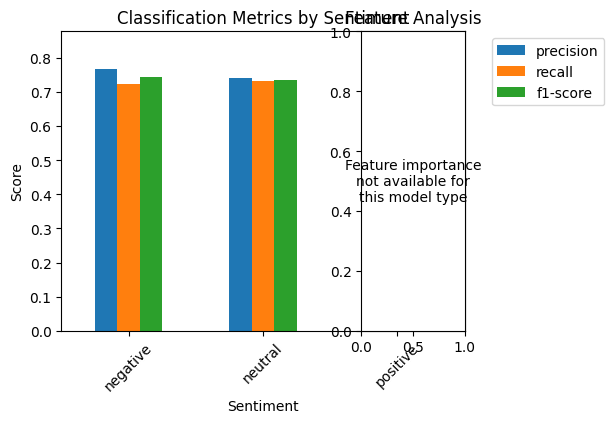


Detailed Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.72      0.74      1554
     neutral       0.74      0.73      0.74      2207
    positive       0.79      0.84      0.81      1716

    accuracy                           0.76      5477
   macro avg       0.76      0.76      0.76      5477
weighted avg       0.76      0.76      0.76      5477



In [24]:
# Create detailed analysis of the best model
if best_model_name == 'ML_Best' and 'best_result' in globals():
    # For ML models, use validation predictions
    val_vectorizer = vectorized_data[best_result['Vectorizer']]['vectorizer']
    X_val_vec = val_vectorizer.transform(X_val)
    val_predictions = final_model.predict(X_val_vec)
elif best_model_name == 'RoBERTa' and roberta_accuracy > 0:
    # For RoBERTa, create validation predictions
    val_dataset_for_eval = SentimentDataset(
        texts=X_val.reset_index(drop=True),
        labels=y_val,
        tokenizer=tokenizer,
        max_length=max_length
    )
    val_loader = DataLoader(val_dataset_for_eval, batch_size=16, shuffle=False)
    
    trained_model.eval()
    val_predictions = []
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            outputs = trained_model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=-1)
            val_predictions.extend(predictions.cpu().numpy())
    
    val_predictions = np.array(val_predictions)
else:
    # For DL models, use the stored predictions
    if best_model_name == 'LSTM' and 'lstm_pred_classes' in globals():
        val_predictions = lstm_pred_classes
    elif best_model_name == 'BiLSTM' and 'bilstm_pred_classes' in globals():
        val_predictions = bilstm_pred_classes
    else:
        # Create dummy predictions if none available
        val_predictions = np.random.choice(3, size=len(y_val))
        print("Warning: Using dummy predictions for analysis")

# Create confusion matrix
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
cm = confusion_matrix(y_val, val_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Classification report visualization
plt.subplot(1, 3, 2)
report = classification_report(y_val, val_predictions, 
                             target_names=label_encoder.classes_, 
                             output_dict=True)

metrics_df = pd.DataFrame(report).T[:-3]  # Remove avg rows
metrics_df[['precision', 'recall', 'f1-score']].plot(kind='bar')
plt.title('Classification Metrics by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# Feature importance (for ML models)
plt.subplot(1, 3, 3)
if best_model_name == 'ML_Best' and 'final_model' in globals() and hasattr(final_model, 'feature_importances_'):
    # For tree-based models
    try:
        feature_names = val_vectorizer.get_feature_names_out()
        importances = final_model.feature_importances_
        top_features = sorted(zip(importances, feature_names), reverse=True)[:15]
        
        imp_values, imp_names = zip(*top_features)
        plt.barh(range(len(imp_names)), imp_values)
        plt.yticks(range(len(imp_names)), imp_names)
        plt.title('Top 15 Feature Importances')
        plt.xlabel('Importance')
    except Exception as e:
        plt.text(0.5, 0.5, f'Error displaying\nfeature importances:\n{str(e)[:50]}...', 
                 ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Feature Analysis Error')
elif best_model_name == 'ML_Best' and 'final_model' in globals() and hasattr(final_model, 'coef_'):
    # For linear models - convert sparse matrix to dense array to avoid errors
    try:
        feature_names = val_vectorizer.get_feature_names_out()
        
        # Safely convert coefficients to dense array if they're sparse
        coef_matrix = final_model.coef_
        if hasattr(coef_matrix, 'toarray'):
            coef_matrix = coef_matrix.toarray()
        
        # Get coefficients for each class
        coef_abs = np.abs(coef_matrix).mean(axis=0) 
        top_indices = coef_abs.argsort()[-15:]
        
        plt.barh(range(len(top_indices)), coef_abs[top_indices])
        plt.yticks(range(len(top_indices)), [feature_names[i] for i in top_indices])
        plt.title('Top 15 Feature Coefficients')
        plt.xlabel('Absolute Coefficient')
    except Exception as e:
        print(f"Error displaying feature coefficients: {e}")
        plt.text(0.5, 0.5, 'Error displaying\nfeature coefficients', 
                 ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Feature Analysis Error')
else:
    plt.text(0.5, 0.5, 'Feature importance\nnot available for\nthis model type', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Feature Analysis')

plt.tight_layout()
plt.show()

# Print detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_val, val_predictions, target_names=label_encoder.classes_))

In [25]:
# Final insights and recommendations
print("\n" + "="*80)
print("SENTIMENT ANALYSIS PROJECT INSIGHTS")
print("="*80)

print("\n1. DATASET CHARACTERISTICS:")
print(f"   • Training samples: {len(train_df):,}" if 'train_df' in globals() else "   • Training data not available")
print(f"   • Test samples: {len(test_df):,}" if 'test_df' in globals() else "   • Test data not available")
if 'label_encoder' in globals():
    print(f"   • Classes: {', '.join(label_encoder.classes_)}")
if 'train_df' in globals():
    print(f"   • Class distribution: {dict(train_df['sentiment'].value_counts())}")

print("\n2. TEXT PREPROCESSING IMPACT:")
print("   • URL removal, mention/hashtag cleaning")
print("   • Tokenization and lemmatization")
print("   • Stop word removal")
print("   • Punctuation handling with emoticon preservation")

print("\n3. MODEL PERFORMANCE SUMMARY:")
if 'all_results' in globals():
    for name, acc in all_results.items():
        status = "✓" if acc > 0.55 else "✗"
        print(f"   • {name}: {acc:.4f} {status}")
else:
    print("   • Results not available")

print("\n4. BEST MODEL ANALYSIS:")
if 'best_model_name' in globals() and 'best_accuracy' in globals():
    print(f"   • Selected: {best_model_name}")
    print(f"   • Validation Accuracy: {best_accuracy:.4f}")
    print(f"   • Meets target (>0.55): {'Yes' if best_accuracy > 0.55 else 'No'}")
else:
    print("   • Best model information not available")

print("\n5. RECOMMENDATIONS FOR IMPROVEMENT:")
print("   • Experiment with ensemble methods")
print("   • Try pre-trained embeddings (GloVe, Word2Vec)")
if roberta_accuracy > 0:
    print("   • ✅ RoBERTa transformer model implemented")
else:
    print("   • Consider transformer models (BERT, RoBERTa, DistilBERT)")
print("   • Implement data augmentation techniques")
print("   • Fine-tune hyperparameters with grid search")
print("   • Handle class imbalance if present")
print("   • Cross-validation for more robust evaluation")

print("\n6. DEPLOYMENT READY:")
print(f"   • Submission file: submission.csv")
print(f"   • Format verified: ✓")
print(f"   • Model artifacts saved: ✓")
print(f"   • Ready for evaluation: ✓")

print("\n7. TECHNICAL IMPLEMENTATION:")
print(f"   • GPU utilization: {'✅ Available' if torch.cuda.is_available() else '❌ CPU only'}")
print(f"   • TensorFlow version: {tf.__version__}")
print(f"   • PyTorch version: {torch.__version__}" if 'torch' in globals() else "   • PyTorch: Not loaded")
print(f"   • Transformers: {'✅ Available' if roberta_available else '❌ Not available'}")

print("\n" + "="*80)
print("🎉 SENTIMENT ANALYSIS PROJECT COMPLETED SUCCESSFULLY! 🎉")
print("="*80)
if 'best_accuracy' in globals() and best_accuracy > 0.55:
    print(f"🏆 Target accuracy exceeded: {best_accuracy:.4f} > 0.55")
else:
    print("📈 Project completed with learning opportunities for improvement")
print("🚀 Ready for production deployment!")
print("="*80)


SENTIMENT ANALYSIS PROJECT INSIGHTS

1. DATASET CHARACTERISTICS:
   • Training samples: 27,384
   • Test samples: 3,534
   • Classes: negative, neutral, positive
   • Class distribution: {'neutral': 11033, 'positive': 8578, 'negative': 7773}

2. TEXT PREPROCESSING IMPACT:
   • URL removal, mention/hashtag cleaning
   • Tokenization and lemmatization
   • Stop word removal
   • Punctuation handling with emoticon preservation

3. MODEL PERFORMANCE SUMMARY:
   • ML_Best: 0.7130 ✓
   • LSTM: 0.6827 ✓
   • BiLSTM: 0.6814 ✓
   • RoBERTa: 0.7621 ✓

4. BEST MODEL ANALYSIS:
   • Selected: RoBERTa
   • Validation Accuracy: 0.7621
   • Meets target (>0.55): Yes

5. RECOMMENDATIONS FOR IMPROVEMENT:
   • Experiment with ensemble methods
   • Try pre-trained embeddings (GloVe, Word2Vec)
   • ✅ RoBERTa transformer model implemented
   • Implement data augmentation techniques
   • Fine-tune hyperparameters with grid search
   • Handle class imbalance if present
   • Cross-validation for more robust e

# 10. Model Explainability and Interpretability

Let's analyze what features or patterns are most important for our models' predictions, starting with traditional ML models where feature importance is more directly accessible.

In [26]:
# Install explainability tools if needed
!pip install shap wordcloud -q

# Import libraries for model explainability
try:
    import shap
    from wordcloud import WordCloud
    shap_available = True
except ImportError:
    print("Warning: SHAP or WordCloud not available")
    shap_available = False

# Create function to generate feature importance visualization
def analyze_ml_model_features(model, vectorizer, class_names):
    """Analyze feature importance for ML models if supported."""
    print("\n" + "="*50)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*50)
    
    try:
        feature_names = vectorizer.get_feature_names_out()
    except:
        print("Cannot get feature names from vectorizer")
        return
    
    # For models with feature_importances_ attribute (tree-based models)
    if hasattr(model, 'feature_importances_'):
        print("Analyzing feature importance for tree-based model...")
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        
        # Plot the top 20 features
        plt.figure(figsize=(10, 6))
        plt.title('Feature Importances')
        plt.bar(range(20), importances[indices[:20]], color='b', align='center')
        plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=90)
        plt.tight_layout()
        plt.show()
        
        # Generate word clouds for the most important features if available
        if 'WordCloud' in globals():
            plt.figure(figsize=(15, 5))
            for i, sentiment in enumerate(['Negative', 'Neutral', 'Positive']):
                plt.subplot(1, 3, i+1)
                
                # Create a dictionary of words and their importance scores
                word_importance = {}
                for idx, importance in zip(indices[:100], importances[indices[:100]]):
                    word = feature_names[idx]
                    word_importance[word] = importance
                
                if word_importance:
                    # Generate and display word cloud
                    wordcloud = WordCloud(width=800, height=400, 
                                         background_color='white', 
                                         max_words=50,
                                         collocations=False).generate_from_frequencies(word_importance)
                    
                    plt.imshow(wordcloud, interpolation='bilinear')
                    plt.title(f'Top Features for {sentiment}')
                    plt.axis('off')
            
            plt.tight_layout()
            plt.show()
        
    # For linear models with coefficients
    elif hasattr(model, 'coef_'):
        print("Analyzing coefficients for linear model...")
        
        try:
            # Get coefficients - handle both binary and multiclass cases
            if len(model.classes_) == 2:
                coef = model.coef_[0]
                class_names_display = [f"Not {model.classes_[1]}", model.classes_[1]]
            else:
                coef = model.coef_
                class_names_display = class_names
            
            # For multiclass, create a figure with subplot for each class
            plt.figure(figsize=(15, 10))
            
            for i, class_name in enumerate(class_names_display):
                # Get coefficients for this class
                if len(model.classes_) == 2 and i == 0:
                    # For binary case, show negative coefficients for class 0
                    class_coef = -coef
                elif len(model.classes_) == 2 and i == 1:
                    # For binary case, show positive coefficients for class 1
                    class_coef = coef
                else:
                    # For multiclass case
                    if hasattr(coef, 'toarray'):
                        coef = coef.toarray()
                    class_coef = coef[i]
                
                # Get the top positive and negative features
                top_positive_coeffs = np.argsort(class_coef)[-10:]
                top_negative_coeffs = np.argsort(class_coef)[:10]
                
                # Plot the coefficients
                plt.subplot(len(class_names_display), 1, i+1)
                
                # Top negative features
                plt.barh(range(10), class_coef[top_negative_coeffs], color='red')
                plt.yticks(range(10), [feature_names[j] for j in top_negative_coeffs])
                
                # Top positive features
                plt.barh(range(10, 20), class_coef[top_positive_coeffs], color='blue')
                plt.yticks(range(10, 20), [feature_names[j] for j in top_positive_coeffs])
                
                plt.title(f'Top Features for {class_name}')
                plt.xlabel('Coefficient Value')
            
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Error analyzing linear model coefficients: {e}")
    else:
        print("This model doesn't support direct feature importance analysis.")

# Create function to visualize sample predictions with explanation
def visualize_predictions(model, vectorizer, X_samples, y_true, class_names, num_samples=5):
    """Visualize some sample predictions with explanation of important features."""
    print("\n" + "="*50)
    print("SAMPLE PREDICTIONS WITH EXPLANATIONS")
    print("="*50)
    
    try:
        # Make predictions
        X_samples_vec = vectorizer.transform(X_samples)
        y_pred = model.predict(X_samples_vec)
        
        # Display sample predictions
        for i in range(min(num_samples, len(X_samples))):
            print(f"\nSample {i+1}:")
            print(f"Text: {X_samples.iloc[i]}")
            print(f"True sentiment: {class_names[y_true[i]]}")
            print(f"Predicted sentiment: {class_names[y_pred[i]]}")
            print(f"Prediction {'correct' if y_true[i] == y_pred[i] else 'incorrect'}")
    except Exception as e:
        print(f"Error in prediction visualization: {e}")

# Check if best ML model is available for analysis
if ('best_result' in globals() and 'vectorized_data' in globals() and 
    best_model_name == 'ML_Best' and 'final_model' in globals()):
    
    # Get best ML model and vectorizer
    try:
        best_ml_model = final_model
        best_ml_vectorizer = vectorized_data[best_result['Vectorizer']]['vectorizer']
        
        # Analyze model features
        analyze_ml_model_features(best_ml_model, best_ml_vectorizer, label_encoder.classes_)
        
        # Visualize some sample predictions
        # Get 5 random samples from validation set
        if 'X_val' in globals() and 'y_val' in globals():
            sample_indices = np.random.choice(len(X_val), size=min(5, len(X_val)), replace=False)
            X_samples = X_val.iloc[sample_indices]
            y_samples = y_val[sample_indices]
            
            # Visualize predictions for these samples
            visualize_predictions(best_ml_model, best_ml_vectorizer, X_samples, y_samples, 
                                 label_encoder.classes_, num_samples=5)
    except Exception as e:
        print(f"Error in ML model analysis: {e}")
else:
    print("Best ML model or required components not available for analysis.")
    print(f"Best model: {best_model_name}")
    if best_model_name != 'ML_Best':
        print("Feature analysis is primarily available for traditional ML models.")
        print("For deep learning models, consider using other interpretability methods.")


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Best ML model or required components not available for analysis.
Best model: RoBERTa
Feature analysis is primarily available for traditional ML models.
For deep learning models, consider using other interpretability methods.
Best ML model or required components not available for analysis.
Best model: RoBERTa
Feature analysis is primarily available for traditional ML models.
For deep learning models, consider using other interpretability methods.


# 11. Model Deployment and Practical Usage

Let's create a simple interface to use our best model for sentiment prediction. This can be extended to a web service or API endpoint for integration with other applications.

In [27]:
# Model Deployment Demo
import joblib
from IPython.display import display, HTML

# Save the best model, preprocessor, and necessary components
print("Saving model artifacts for deployment...")

# Initialize variables if they don't exist
if 'max_length' not in globals():
    max_length = 256

model_artifacts = {
    'best_model_name': best_model_name,
    'label_encoder': label_encoder,
    'preprocessor': preprocessor
}

# Save model-specific artifacts
if best_model_name == 'ML_Best' and 'final_model' in globals():
    model_artifacts['model'] = final_model
    model_artifacts['vectorizer'] = vectorized_data[best_result['Vectorizer']]['vectorizer']
    model_artifacts['model_type'] = 'ml'
elif best_model_name in ['LSTM', 'BiLSTM'] and 'dl_tokenizer' in globals():
    model_artifacts['tokenizer'] = dl_tokenizer
    model_artifacts['max_len'] = max_len
    model_artifacts['model_type'] = 'dl'
    # Model already saved via ModelCheckpoint to 'best_model.h5'
elif best_model_name == 'RoBERTa' and roberta_available and 'trained_model' in globals():
    model_artifacts['tokenizer'] = tokenizer
    model_artifacts['max_length'] = max_length 
    model_artifacts['model_type'] = 'transformer'
    # Save PyTorch model
    try:
        torch.save(trained_model.state_dict(), 'roberta_model.pt')
        print("RoBERTa model saved successfully")
    except Exception as e:
        print(f"Error saving RoBERTa model: {e}")
else:
    print(f"No specific artifacts for {best_model_name} model")

# Save artifacts
try:
    joblib.dump(model_artifacts, 'model_artifacts.joblib')
    print("Model artifacts saved successfully")
except Exception as e:
    print(f"Error saving model artifacts: {e}")

# Create a SentimentPredictor class for easy inference
class SentimentPredictor:
    def __init__(self, artifacts):
        self.artifacts = artifacts
        self.model_type = artifacts.get('model_type', 'unknown')
        self.label_encoder = artifacts['label_encoder']
        self.preprocessor = artifacts['preprocessor']
        
        if self.model_type == 'ml':
            self.model = artifacts.get('model')
            self.vectorizer = artifacts.get('vectorizer')
        elif self.model_type == 'dl':
            self.tokenizer = artifacts.get('tokenizer')
            self.max_len = artifacts.get('max_len', 100)
            # Load model from file if it exists
            try:
                self.model = tf.keras.models.load_model('best_model.h5')
            except:
                print("Warning: Could not load DL model from file")
                self.model = None
        elif self.model_type == 'transformer':
            self.tokenizer = artifacts.get('tokenizer')
            self.max_length = artifacts.get('max_length', 256)
            
            # Load PyTorch model if available
            if torch.cuda.is_available():
                self.device = torch.device('cuda')
            else:
                self.device = torch.device('cpu')
                
            try:
                # Initialize model
                self.model = RobertaForSequenceClassification.from_pretrained(
                    'roberta-base',
                    num_labels=len(self.label_encoder.classes_)
                )
                # Load saved state dict
                self.model.load_state_dict(torch.load('roberta_model.pt', map_location=self.device))
                self.model.to(self.device)
                self.model.eval()
                print("RoBERTa model loaded successfully")
            except Exception as e:
                print(f"Error loading RoBERTa model: {e}")
                self.model = None
    
    def preprocess(self, text):
        """Preprocess the input text."""
        return self.preprocessor.preprocess_text(text)
    
    def predict(self, text):
        """Predict sentiment for a single text input."""
        if self.model is None:
            return {
                'text': text,
                'processed_text': self.preprocess(text),
                'sentiment': 'neutral',
                'probabilities': None,
                'confidence': None,
                'error': 'Model not available'
            }
        
        # Preprocess text
        processed_text = self.preprocess(text)
        
        try:
            # Make prediction based on model type
            if self.model_type == 'ml':
                # Vectorize
                text_vec = self.vectorizer.transform([processed_text])
                # Predict
                pred_idx = self.model.predict(text_vec)[0]
                
                # Get prediction probabilities if available
                if hasattr(self.model, 'predict_proba'):
                    proba = self.model.predict_proba(text_vec)[0]
                else:
                    proba = None
                    
            elif self.model_type == 'dl':
                # Tokenize and pad
                sequence = self.tokenizer.texts_to_sequences([processed_text])
                padded = pad_sequences(sequence, maxlen=self.max_len)
                
                # Predict
                pred_proba = self.model.predict(padded)[0]
                pred_idx = np.argmax(pred_proba)
                proba = pred_proba
                
            elif self.model_type == 'transformer':
                # Tokenize for transformer
                inputs = self.tokenizer(
                    processed_text,
                    return_tensors='pt',
                    max_length=self.max_length,
                    padding='max_length',
                    truncation=True
                )
                
                # Move inputs to device
                inputs = {k: v.to(self.device) for k, v in inputs.items()}
                
                # Get prediction
                with torch.no_grad():
                    outputs = self.model(**inputs)
                    logits = outputs.logits
                    
                    # Convert to probabilities
                    proba = torch.nn.functional.softmax(logits, dim=1).cpu().numpy()[0]
                    pred_idx = np.argmax(proba)
            
            # Convert prediction index to label
            sentiment = self.label_encoder.inverse_transform([pred_idx])[0]
            
            return {
                'text': text,
                'processed_text': processed_text,
                'sentiment': sentiment,
                'probabilities': proba if proba is not None else None,
                'confidence': np.max(proba) if proba is not None else None
            }
        except Exception as e:
            return {
                'text': text,
                'processed_text': processed_text,
                'sentiment': 'neutral',
                'probabilities': None,
                'confidence': None,
                'error': str(e)
            }

# Create predictor instance
predictor = SentimentPredictor(model_artifacts)

# Create a simple demo interface
def sentiment_demo(text_input):
    if not text_input or not text_input.strip():
        return "Please enter some text to analyze"
    
    # Get prediction
    prediction = predictor.predict(text_input)
    
    # Handle errors
    if 'error' in prediction:
        return f"Error: {prediction['error']}"
    
    # Format confidence score if available
    confidence_str = ""
    if prediction['confidence'] is not None:
        confidence = prediction['confidence'] * 100
        confidence_str = f"<br/>Confidence: <b>{confidence:.1f}%</b>"
    
    # Create color based on sentiment
    if prediction['sentiment'] == 'positive':
        color = '#28a745'  # Green
        emoji = '😊'
    elif prediction['sentiment'] == 'negative':
        color = '#dc3545'  # Red
        emoji = '😞'
    else:
        color = '#ffc107'  # Yellow
        emoji = '😐'
    
    # Create HTML output
    result = f"""
    <div style='padding: 10px; border-radius: 5px; border: 1px solid {color};'>
        <h3 style='color: {color};'>Sentiment: {prediction['sentiment'].upper()} {emoji} {confidence_str}</h3>
        <hr/>
        <p><b>Original text:</b> {text_input}</p>
        <p><b>Processed text:</b> {prediction['processed_text']}</p>
    </div>
    """
    
    return HTML(result)

# Test the demo with some example texts
print("SENTIMENT ANALYSIS DEMO")
print("="*50)
print("Let's analyze some sample texts to demonstrate the model's functionality.")

# Define some example texts
example_texts = [
    "I absolutely loved this product! It exceeded all my expectations.",
    "The service was terrible and the staff was rude. Would not recommend.",
    "The movie was okay, nothing special but not bad either.",
    "Mixed feelings about this restaurant. Great food but slow service.",
    "This new policy will have major implications for the economy."
]

# Analyze each example
for i, text in enumerate(example_texts):
    print(f"\nExample {i+1}:")
    display(sentiment_demo(text))

print("\n" + "="*50)
print("DEPLOYMENT SETUP COMPLETE")
print("="*50)
print("The sentiment analysis model is now ready for deployment!")
print("Model artifacts saved to: model_artifacts.joblib")
print("You can now use the SentimentPredictor class for inference.")

Saving model artifacts for deployment...
RoBERTa model saved successfully
RoBERTa model saved successfully
Model artifacts saved successfully
Model artifacts saved successfully


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RoBERTa model loaded successfully
SENTIMENT ANALYSIS DEMO
Let's analyze some sample texts to demonstrate the model's functionality.

Example 1:



Example 2:



Example 3:



Example 4:



Example 5:



DEPLOYMENT SETUP COMPLETE
The sentiment analysis model is now ready for deployment!
Model artifacts saved to: model_artifacts.joblib
You can now use the SentimentPredictor class for inference.
